# Saving resulting files
If you _know_ that code generation from a specific prompt works in the vast majority of cases, you may want to execute code-generation once and go ahead to process the result, e.g. by accessing the file where a plot is stored. You can approach such scenarios like this:

In [1]:
from sand_bob import generate_code, config_scadsai_llm
config_scadsai_llm()


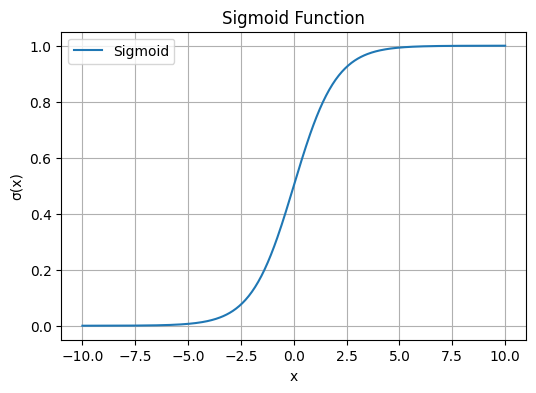
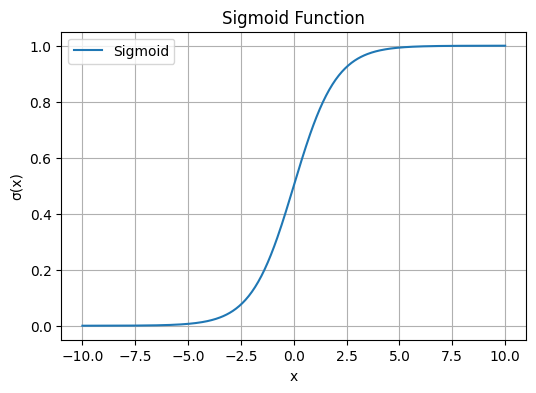

Output()

ExecutionResult(stdout='[jupytext] Reading notebook.mystnb in format mystnb\n[jupytext] Writing notebook.ipynb\n[NbConvertApp] Converting notebook notebook.ipynb to notebook\n[NbConvertApp] Writing 30217 bytes to /display_output/notebook_executed.ipynb\n', stderr='', exit_code=0, execution_time=4.734773635864258, run_time=4.667710065841675, build_time=0.0, container_id='4a82347dd1c60a50ef4af11d7f51fc7ea6b56471d601447e90aefdac0ef27ddd', prompt='\nYou are an expert in python programming. You have a list of framework constraints which you MUST follow.\nYour task is to generate a fully functional code snippet that will be used to fulfill the prompt.\nAssume your code will be executed in a Jupyter notebook cell.\n\n# Framework constraints\n* You may use the following libraries, but only if necessary: numpy, seaborn, matplotlib\n* pip install is STRICTLY PROHIBITED. You can only use the libraries mentioned above.\n* Statistics: When applying statisticals test, ENSURE that pre-conditions for the tests are checked before the tests are performed.\n* Final result output (print or display calls): \n  * The second-last print or display call should be a description of the result (e.g. the measurment and a physical unit if relevant).\n  * The last print or display call should be the final result ONLY.\n  * If the task is to generate a count, ratio or measurements, print the final result using a separate `print` call. \n  * If the task is to answer a yes/no question, print "Yes" or "No" using a separate `print` call. Do not create any JSON for this.\n  * If the task is to generate a plot, display the plot.\n  * Also plot intermediate results if possible.\n* Final result output (file writing):\n  * If the task is to generate a text or a string, write the text or string to "/display_output/final_result.txt".\n  * If the task is to generate a table, write the table to "/display_output/final_result.csv".\n  * If the task is to generate a number, list, array or dictionary, write the result to "/display_output/final_result.json".\n    In that case, do not add additional data structures. Simply json.dump the result to the file. E.g. if the result is x=2, then just do `json.dump(x, fp)`.\n* Keep the code short and concise.\n\n\n\nGiven some task, code to fulfill the task, and detailed feedback, propose new code that incorporates the feedback.\nMake sure to keep the code format.\n\n# Task\n                \nPlot a sigmoid\n                \n# Code\n\n```\n# import required libraries\nimport numpy as np\nimport matplotlib.pyplot as plt\n\n# generate data for the sigmoid\nx = np.linspace(-10, 10, 400)\nsigmoid = 1 / (1 + np.exp(-x))\n\n# plot the sigmoid\nplt.figure(figsize=(6, 4))\nplt.plot(x, sigmoid, label=\'Sigmoid\')\nplt.title(\'Sigmoid Function\')\nplt.xlabel(\'x\')\nplt.ylabel(\'σ(x)\')\nplt.grid(True)\nplt.legend()\n\n# description of the plotted result\nprint("Sigmoid function plotted over the range [-10, 10]")\n\n# display the plot\nplt.show()\n```\n\n# Feedback\n\nThe code is functional, but it fails to meet the project requirements regarding the saving and outputting of final plots.\n\n**Final result handling**\nThe task requires that final plots be saved in the `/display_output` folder as both `.png` and `.svg` files, and that the filenames be printed.\n\nOld code:\n```python\n# display the plot\nplt.show()\n```\n\nNew code:\n```python\nimport os\n\n# Ensure directory exists\nos.makedirs(\'/display_output\', exist_ok=True)\n\n# Save the plot\nplt.savefig(\'/display_output/sigmoid_plot.png\')\nplt.savefig(\'/display_output/sigmoid_plot.svg\')\n\n# Display the plot\nplt.show()\n\n# Final output\nprint(\'/display_output/sigmoid_plot.png\')\nprint(\'/display_output/sigmoid_plot.svg\')\n```\n\n**Other suggestions**\n*   The print statement describing the result is redundant; the final output should only contain the required results (filenames in this case).\n\n# Your task\nProvide the updated code to incorporate the feedback. Also make sure th

In [2]:
result = generate_code("Plot a sigmoid", dependencies=["numpy", "seaborn", "matplotlib"])
result

After execution, saved files are stored:

In [3]:
list(result.files.keys())

['/display_output/notebook_executed.ipynb',
 '/display_output/sigmoid_plot.png',
 '/display_output/sigmoid_plot.svg']

One can access the byte arrays of the files like this:

In [4]:
result.files['/display_output/sigmoid_plot.svg']

b'<?xml version="1.0" encoding="utf-8" standalone="no"?>\n<!DOCTYPE svg PUBLIC "-//W3C//DTD SVG 1.1//EN"\n  "http://www.w3.org/Graphics/SVG/1.1/DTD/svg11.dtd">\n<svg xmlns:xlink="http://www.w3.org/1999/xlink" width="432pt" height="288pt" viewBox="0 0 432 288" xmlns="http://www.w3.org/2000/svg" version="1.1">\n <metadata>\n  <rdf:RDF xmlns:dc="http://purl.org/dc/elements/1.1/" xmlns:cc="http://creativecommons.org/ns#" xmlns:rdf="http://www.w3.org/1999/02/22-rdf-syntax-ns#">\n   <cc:Work>\n    <dc:type rdf:resource="http://purl.org/dc/dcmitype/StillImage"/>\n    <dc:date>2026-05-23T16:13:36.568116</dc:date>\n    <dc:format>image/svg+xml</dc:format>\n    <dc:creator>\n     <cc:Agent>\n      <dc:title>Matplotlib v3.10.9, https://matplotlib.org/</dc:title>\n     </cc:Agent>\n    </dc:creator>\n   </cc:Work>\n  </rdf:RDF>\n </metadata>\n <defs>\n  <style type="text/css">*{stroke-linejoin: round; stroke-linecap: butt}</style>\n </defs>\n <g id="figure_1">\n  <g id="patch_1">\n   <path d="M 0 